# CineMatch few-shot new-user evaluation

This notebook evaluates a question not answered by the publication audit: how well do the semantic and graph-CF paths adapt to a genuinely new user after only 0, 1, 3, 5, or 10 positive ratings?

The design is intentionally strict:

- Development users have no event at or before the development cutoff; their first events occur in the validation window.
- Final-test users have no event at or before the final cutoff; their first events occur in the untouched test window.
- Consequently, none of these users contributed an edge to the corresponding trained graph model.
- Every evaluated support, target, and candidate item belongs to a common frozen catalog that BGE/FAISS, BPR, LightGCN, and XSimGCL can all represent.
- Semantic retrieval searches an exact stage-specific FAISS index built only from that common catalog, so every method ranks the identical candidate space.
- Positive events 11-20 are fixed targets for all shot counts; only the revealed prefix changes.
- Fusion weights are selected on development new users and frozen before final testing.
- The graph paths synthesize a new-user vector only from revealed item embeddings; saved trained user embeddings are never used.
- Each expensive output is cached under outputs/publication_audit/fewshot_new_user_eval.

Run the notebook from top to bottom. It does not retrain any model and does not modify the earlier publication artifacts.


In [1]:
# Configuration, Drive mount, and paths
from pathlib import Path
from collections import Counter, defaultdict
import gc, gzip, hashlib, json, math, pickle, platform, random, subprocess, sys, time

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

SEED = 42
POSITIVE_THRESHOLD = 4.0
CF_TRAIN_POSITIVE_THRESHOLD = 3.5
SHOTS = (0, 1, 3, 5, 10)
TARGETS_PER_USER = 10
MAX_USERS_PER_STAGE = 1000
EXCLUDE_TIMESTAMP_BOUNDARY_TIES = True
SEM_NEIGHBORS_PER_QUERY = 2000
SEM_POOL = 2000
CF_POOL = 1000
OUTPUT_K = 100
TOPK_VALUES = (10, 20, 50)
CF_BATCH = 256
SEM_QUERY_BATCH = 1024
BOOTSTRAP_REPLICATES = 5000
FORCE_RECOMPUTE = False

import numpy as np
import pandas as pd
from IPython.display import display

BASE_CANDIDATES = [
    Path('/content/drive/MyDrive/cinematch'),
    Path('.').resolve(),
]

def resolve_base():
    for base in BASE_CANDIDATES:
        if (base / 'Data/ml-32m/ratings.csv').exists() and (base / 'outputs/publication_audit/publication_eval/models').exists():
            return base
    raise FileNotFoundError(
        'Expected Data/ml-32m and outputs/publication_audit/publication_eval/models under the CineMatch project root.'
    )

BASE = resolve_base()
AUDIT = BASE / 'outputs/publication_audit'
PUB_EVAL = AUDIT / 'publication_eval'
FEW_OUT = AUDIT / 'fewshot_new_user_eval'
FEW_OUT.mkdir(parents=True, exist_ok=True)

RATINGS_PATH = BASE / 'Data/ml-32m/ratings.csv'
LINKS_PATH = BASE / 'Data/ml-32m/links.csv'
SPLIT_MANIFEST_PATH = AUDIT / 'global_time_split_manifest.json'
CATALOG_CANDIDATES = [
    BASE / 'Data/tmdb_semantic_catalog_alllangs_with_new_movies.csv',
]
INDEX_CANDIDATES = [
    BASE / 'outputs/tmdb/bge/tmdb_bge_m3_flatip.faiss',
]
CATALOG_PATH = next((p for p in CATALOG_CANDIDATES if p.exists()), None)
INDEX_PATH = next((p for p in INDEX_CANDIDATES if p.exists()), None)
assert CATALOG_PATH and INDEX_PATH
INDEX_MANIFEST_PATH = INDEX_PATH.with_name('tmdb_bge_m3_build_manifest.json')
assert INDEX_MANIFEST_PATH.exists()
assert SPLIT_MANIFEST_PATH.exists()

def sha256_file(path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()

def stable_hash(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':')).encode()).hexdigest()[:16]

split_manifest = json.loads(SPLIT_MANIFEST_PATH.read_text())
DEV_CUTOFF = int(split_manifest['development_cutoff_unix'])
FINAL_CUTOFF = int(split_manifest['validation_cutoff_unix'])
print('Base:', BASE)
print('Output:', FEW_OUT)
print('Development cutoff:', pd.to_datetime(DEV_CUTOFF, unit='s', utc=True))
print('Final cutoff:', pd.to_datetime(FINAL_CUTOFF, unit='s', utc=True))


Mounted at /content/drive
Base: /content/drive/MyDrive/cinematch
Output: /content/drive/MyDrive/cinematch/outputs/publication_audit/fewshot_new_user_eval
Development cutoff: 2018-10-03 07:21:40+00:00
Final cutoff: 2020-11-05 19:45:33+00:00


In [2]:
# Install only the retrieval/runtime dependencies; RecBole and retraining are not needed.
try:
    import faiss
except ImportError:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', 'faiss-gpu-cu12>=1.8.0,<2.0.0'],
        check=True,
    )
    import faiss

import torch
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
print('Device:', DEVICE, '| Torch:', torch.__version__, '| FAISS:', getattr(faiss, '__version__', 'unknown'))


Device: cuda | Torch: 2.11.0+cu128 | FAISS: 1.14.1


In [3]:
# Load model maps and construct a common, frozen item catalog for fair path comparison.
MODEL_NAMES = ('BPR', 'LightGCN', 'XSimGCL')

def model_root(stage, model):
    return PUB_EVAL / 'models' / stage / model.lower()

def load_item_map(stage, model):
    path = model_root(stage, model) / 'item_map.json'
    assert path.exists(), f'Missing {path}'
    return {int(k): int(v) for k, v in json.loads(path.read_text()).items()}

candidate_files = {
    'development': AUDIT / 'global_time_development_candidate_movie_ids.csv',
    'final': AUDIT / 'global_time_final_candidate_movie_ids.csv',
}
candidate_catalogs = {
    stage: set(pd.read_csv(path).movieId.astype(int))
    for stage, path in candidate_files.items()
}
item_maps = {
    stage: {model: load_item_map(stage, model) for model in MODEL_NAMES}
    for stage in ('development', 'final')
}

links = pd.read_csv(LINKS_PATH, usecols=['movieId', 'tmdbId'])
links['tmdbId'] = pd.to_numeric(links.tmdbId, errors='coerce')
ml_to_tmdb = {
    int(mid): int(tid) for mid, tid in zip(links.movieId, links.tmdbId) if pd.notna(tid)
}
catalog = pd.read_csv(
    CATALOG_PATH,
    usecols=lambda c: c in {'id', 'original_language'},
    low_memory=False,
)
catalog['id'] = pd.to_numeric(catalog.id, errors='coerce')
catalog = catalog.dropna(subset=['id']).drop_duplicates('id')
tmdb_to_language = {
    int(row.id): (None if pd.isna(row.original_language) else str(row.original_language).strip().lower())
    for row in catalog[['id', 'original_language']].itertuples(index=False)
}
language_map = {mid: tmdb_to_language.get(tid) for mid, tid in ml_to_tmdb.items()}

# This FAISS file is IndexIDMap2: its external IDs are TMDB IDs. Cache that ID list
# so resume runs need not load the 5 GB index merely to rebuild the common catalog.
index_stat = INDEX_PATH.stat()
index_id_cache = FEW_OUT / f'tmdb_index_ids_{stable_hash({"size": index_stat.st_size, "mtime": index_stat.st_mtime_ns})}.npy'
cpu_index = None
if index_id_cache.exists() and not FORCE_RECOMPUTE:
    indexed_tmdb_ids_array = np.load(index_id_cache)
else:
    print('Loading TMDB IndexIDMap2 to validate its embedded IDs...')
    cpu_index = faiss.read_index(str(INDEX_PATH))
    assert isinstance(cpu_index, faiss.IndexIDMap2), f'Expected IndexIDMap2, found {type(cpu_index).__name__}'
    indexed_tmdb_ids_array = faiss.vector_to_array(cpu_index.id_map).astype(np.int64)
    assert len(indexed_tmdb_ids_array) == cpu_index.ntotal
    assert len(np.unique(indexed_tmdb_ids_array)) == len(indexed_tmdb_ids_array)
    np.save(index_id_cache, indexed_tmdb_ids_array)
indexed_tmdb_ids = set(map(int, indexed_tmdb_ids_array))
catalog_tmdb_ids = set(catalog.id.astype(np.int64))
assert indexed_tmdb_ids.issubset(catalog_tmdb_ids)
tmdb_index_manifest = json.loads(INDEX_MANIFEST_PATH.read_text())
manifest_ntotal = int(tmdb_index_manifest.get('faiss', {}).get('ntotal', len(indexed_tmdb_ids)))
assert manifest_ntotal == len(indexed_tmdb_ids), (manifest_ntotal, len(indexed_tmdb_ids))
delta_files = sorted(INDEX_PATH.parent.glob('delta_*.npy'))
if delta_files:
    print('Ignoring', len(delta_files), 'legacy delta files: the dated full IndexIDMap2 rebuild is authoritative.')
movie_to_semantic_id = {
    movie_id: tmdb_id for movie_id, tmdb_id in ml_to_tmdb.items()
    if tmdb_id in indexed_tmdb_ids
}
print('TMDB semantic index IDs:', len(indexed_tmdb_ids), '| catalog rows skipped by index:', len(catalog_tmdb_ids - indexed_tmdb_ids))

common_catalogs = {}
for stage in ('development', 'final'):
    common = set(candidate_catalogs[stage]).intersection(movie_to_semantic_id)
    for model in MODEL_NAMES:
        common.intersection_update(item_maps[stage][model])
    # MovieLens contains a small number of duplicate aliases for the same TMDB title.
    # Retain one deterministic MovieLens ID per title to prevent recommending the same film twice.
    canonical_by_tmdb = {}
    for movie_id in sorted(common):
        canonical_by_tmdb.setdefault(movie_to_semantic_id[movie_id], movie_id)
    duplicate_aliases_removed = len(common) - len(canonical_by_tmdb)
    common = set(canonical_by_tmdb.values())
    common_catalogs[stage] = sorted(common)
    print(
        stage,
        '| frozen candidates:', len(candidate_catalogs[stage]),
        '| common BGE/BPR/LightGCN/XSimGCL catalog:', len(common),
        f'({len(common)/len(candidate_catalogs[stage]):.1%})',
        '| duplicate TMDB aliases removed:', duplicate_aliases_removed,
    )
    assert len({movie_to_semantic_id[mid] for mid in common}) == len(common)
    assert len(common) > 10000


Loading TMDB IndexIDMap2 to validate its embedded IDs...
Ignoring 4 legacy delta files: the dated full IndexIDMap2 rebuild is authoritative.
TMDB semantic index IDs: 1319414 | catalog rows skipped by index: 5619
development | frozen candidates: 50977 | common BGE/BPR/LightGCN/XSimGCL catalog: 36605 (71.8%) | duplicate TMDB aliases removed: 10
final | frozen candidates: 65723 | common BGE/BPR/LightGCN/XSimGCL catalog: 47544 (72.3%) | duplicate TMDB aliases removed: 17


In [4]:
# Read ratings once and build genuinely new-user development and final cohorts.
rating_dtype = {
    'userId': 'int32', 'movieId': 'int32',
    'rating': 'float32', 'timestamp': 'int32',
}
started = time.time()
ratings = pd.read_csv(
    RATINGS_PATH,
    usecols=['userId', 'movieId', 'rating', 'timestamp'],
    dtype=rating_dtype,
)
print(f'Loaded {len(ratings):,} ratings in {(time.time()-started):.1f}s')

def build_new_user_cohort(stage, train_cutoff, window_end, seed):
    common = set(common_catalogs[stage])
    history_users = set(ratings.loc[ratings.timestamp.le(train_cutoff), 'userId'].astype(int).unique())
    window_mask = ratings.timestamp.gt(train_cutoff)
    if window_end is not None:
        window_mask &= ratings.timestamp.le(window_end)

    window = ratings.loc[
        window_mask
        & ratings.rating.ge(POSITIVE_THRESHOLD)
        & ratings.movieId.isin(common)
        & ~ratings.userId.isin(history_users),
        ['userId', 'movieId', 'rating', 'timestamp'],
    ].copy()
    window = (
        window.sort_values(['userId', 'timestamp', 'movieId'])
        .drop_duplicates(['userId', 'movieId'], keep='first')
    )

    required_events = max(SHOTS) + TARGETS_PER_USER
    counts = window.groupby('userId').size()
    eligible = set(map(int, counts[counts.ge(required_events)].index))
    prefix = window.loc[window.userId.isin(eligible)].groupby('userId', group_keys=False).head(required_events)
    prefix['position'] = prefix.groupby('userId').cumcount()
    timestamp_wide = prefix.pivot(index='userId', columns='position', values='timestamp')

    boundary_tie_users = set()
    for m in [shot for shot in SHOTS if shot > 0]:
        tied = timestamp_wide.index[timestamp_wide[m - 1].eq(timestamp_wide[m])]
        boundary_tie_users.update(map(int, tied))
    if EXCLUDE_TIMESTAMP_BOUNDARY_TIES:
        eligible.difference_update(boundary_tie_users)

    eligible_array = np.array(sorted(eligible), dtype=np.int64)
    rng = np.random.default_rng(seed)
    take = min(MAX_USERS_PER_STAGE, len(eligible_array))
    selected = sorted(map(int, rng.choice(eligible_array, size=take, replace=False))) if take else []
    selected_rows = prefix.loc[prefix.userId.isin(selected)].sort_values(['userId', 'position'])
    sequences = {
        int(uid): [
            {'movieId': int(row.movieId), 'rating': float(row.rating), 'timestamp': int(row.timestamp)}
            for row in group.itertuples(index=False)
        ]
        for uid, group in selected_rows.groupby('userId', sort=True)
    }

    assert len(sequences) == take and all(len(seq) == required_events for seq in sequences.values())
    assert set(sequences).isdisjoint(history_users)
    audit = {
        'stage': stage,
        'train_cutoff_unix': int(train_cutoff),
        'window_end_unix': None if window_end is None else int(window_end),
        'definition': 'no rating event at or before training cutoff; positives in the next window',
        'positive_threshold': POSITIVE_THRESHOLD,
        'common_catalog_items': len(common),
        'required_positive_events': required_events,
        'eligible_before_timestamp_tie_exclusion': int(len(counts[counts.ge(required_events)])),
        'boundary_tie_users': int(len(boundary_tie_users)),
        'exclude_boundary_ties': EXCLUDE_TIMESTAMP_BOUNDARY_TIES,
        'eligible_after_exclusion': int(len(eligible)),
        'sampled_users': int(take),
        'seed': int(seed),
    }
    return {'stage': stage, 'users': selected, 'sequences': sequences, 'audit': audit}

cohorts = {
    'development': build_new_user_cohort('development', DEV_CUTOFF, FINAL_CUTOFF, SEED + 101),
    'final': build_new_user_cohort('final', FINAL_CUTOFF, None, SEED + 202),
}
cohort_payload = {
    'protocol': {
        'shots': list(SHOTS),
        'targets_per_user': TARGETS_PER_USER,
        'same_users_across_shots': True,
        'fixed_truth': 'positions 11-20 are targets for every shot count',
        'fixed_target_start_zero_based': int(max(SHOTS)),
        'timestamp_warning': 'MovieLens timestamps are rating-event timestamps, not verified watch timestamps.',
        'common_catalog_reason': 'every support, target, and candidate is representable by all compared paths',
    },
    'cohorts': {stage: cohort['audit'] for stage, cohort in cohorts.items()},
}
(FEW_OUT / 'fewshot_cohort_manifest.json').write_text(json.dumps(cohort_payload, indent=2))
display(pd.DataFrame([cohort['audit'] for cohort in cohorts.values()]))


Loaded 32,000,204 ratings in 27.7s


,stage,train_cutoff_unix,window_end_unix,definition,positive_threshold,common_catalog_items,required_positive_events,eligible_before_timestamp_tie_exclusion,boundary_tie_users,exclude_boundary_ties,eligible_after_exclusion,sampled_users,seed
0,development,1538551300,1.604606e+09,no rating event at or before training cutoff; ...,4.0,36605,20,13556,423,True,13133,1000,143
1,final,1604605533,NaN,no rating event at or before training cutoff; ...,4.0,47544,20,12055,447,True,11608,1000,244


## Important protocol interpretation

For shot count m, the first m positive events are revealed, while positive events 11-20 are the fixed targets for every shot count. The same sampled users and targets are therefore used throughout, so changes across shot counts isolate the value of additional revealed ratings.

At zero shots, no personalized semantic or graph vector exists. Only Random and MostPopular are evaluated. Treating a popularity fallback as semantic performance would be misleading.


In [5]:
# Resume-safe exact-FAISS neighbor caches over the identical common candidate catalog.
def neighbor_cache_spec(stage):
    cohort = cohorts[stage]
    support_ids = sorted({
        event['movieId']
        for uid in cohort['users']
        for event in cohort['sequences'][uid][:max(SHOTS)]
    })
    stat_i = INDEX_PATH.stat()
    signature_payload = {
        'stage': stage,
        'users': cohort['users'],
        'support_ids': support_ids,
        'common_catalog_hash': stable_hash(common_catalogs[stage]),
        'neighbors': SEM_NEIGHBORS_PER_QUERY,
        'index_size': stat_i.st_size,
        'index_mtime_ns': stat_i.st_mtime_ns,
        'candidate_space': 'exact IndexFlatIP restricted to the frozen common catalog',
        'protocol_version': 2,
    }
    signature = stable_hash(signature_payload)
    return support_ids, signature, FEW_OUT / f'{stage}_semantic_neighbors_{signature}.pkl.gz'

specs = {stage: neighbor_cache_spec(stage) for stage in ('development', 'final')}
neighbor_caches = {}
missing_stages = []
for stage, (_, _, path) in specs.items():
    if path.exists() and not FORCE_RECOMPUTE:
        with gzip.open(path, 'rb') as stream:
            neighbor_caches[stage] = pickle.load(stream)
        print('Loaded semantic neighbor cache:', stage, len(neighbor_caches[stage]))
    else:
        missing_stages.append(stage)

if missing_stages:
    print('Loading source TMDB IndexIDMap2 once for:', missing_stages)
    if cpu_index is None:
        cpu_index = faiss.read_index(str(INDEX_PATH))
    assert isinstance(cpu_index, faiss.IndexIDMap2)
    current_ids = faiss.vector_to_array(cpu_index.id_map).astype(np.int64)
    assert np.array_equal(current_ids, indexed_tmdb_ids_array)

    for stage in missing_stages:
        support_ids, signature, cache_path = specs[stage]
        common_mids = np.asarray(common_catalogs[stage], dtype=np.int64)
        common_tmdb_ids = np.asarray([movie_to_semantic_id[int(mid)] for mid in common_mids], dtype=np.int64)
        try:
            candidate_vectors = cpu_index.reconstruct_batch(common_tmdb_ids).astype('float32')
        except Exception:
            candidate_vectors = np.vstack([cpu_index.reconstruct(int(tid)) for tid in common_tmdb_ids]).astype('float32')
        norms = np.linalg.norm(candidate_vectors, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        candidate_vectors /= norms
        candidate_position = {int(mid): position for position, mid in enumerate(common_mids)}

        restricted_cpu_index = faiss.IndexFlatIP(candidate_vectors.shape[1])
        restricted_cpu_index.add(candidate_vectors)
        try:
            gpu_resources = faiss.StandardGpuResources()
            semantic_index = faiss.index_cpu_to_gpu(gpu_resources, 0, restricted_cpu_index)
            print(stage, 'restricted semantic index on GPU:', semantic_index.ntotal)
        except Exception as error:
            semantic_index = restricted_cpu_index
            print(stage, 'restricted semantic CPU fallback:', str(error)[:160])

        cache = {}
        search_k = min(SEM_NEIGHBORS_PER_QUERY + 1, len(common_mids))
        for start in range(0, len(support_ids), SEM_QUERY_BATCH):
            batch_ids = support_ids[start:start + SEM_QUERY_BATCH]
            query_positions = np.asarray([candidate_position[int(mid)] for mid in batch_ids], dtype=np.int64)
            queries = np.ascontiguousarray(candidate_vectors[query_positions], dtype='float32')
            _, returned_positions = semantic_index.search(queries, search_k)
            for query_mid, positions in zip(batch_ids, returned_positions):
                ranked = []
                for raw_rank, position in enumerate(positions, start=1):
                    if int(position) < 0:
                        continue
                    candidate = int(common_mids[int(position)])
                    if candidate == int(query_mid):
                        continue
                    ranked.append((candidate, raw_rank))
                    if len(ranked) == SEM_NEIGHBORS_PER_QUERY:
                        break
                assert len(ranked) == min(SEM_NEIGHBORS_PER_QUERY, len(common_mids) - 1)
                cache[int(query_mid)] = ranked
            print(f'{stage} restricted semantic queries: {min(start+len(batch_ids), len(support_ids))}/{len(support_ids)}')
        with gzip.open(cache_path, 'wb') as stream:
            pickle.dump(cache, stream, protocol=pickle.HIGHEST_PROTOCOL)
        neighbor_caches[stage] = cache
        print('Saved:', cache_path.name)

        del semantic_index, restricted_cpu_index, candidate_vectors
        if 'gpu_resources' in globals():
            del gpu_resources
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    del cpu_index
    gc.collect()


Loading source TMDB IndexIDMap2 once for: ['development', 'final']
development restricted semantic index on GPU: 36605
development restricted semantic queries: 1024/1212
development restricted semantic queries: 1212/1212
Saved: development_semantic_neighbors_2d2c782c2fa425c6.pkl.gz
final restricted semantic index on GPU: 47544
final restricted semantic queries: 1024/1349
final restricted semantic queries: 1349/1349
Saved: final_semantic_neighbors_d30566c25c230851.pkl.gz


In [6]:
# Ranking helpers and resume-safe mean-pooled graph-CF proxy scoring.
def support_and_truth(cohort, uid, shot):
    sequence = cohort['sequences'][uid]
    support = [event['movieId'] for event in sequence[:shot]]
    target_start = max(SHOTS)
    truth = {event['movieId'] for event in sequence[target_start:target_start + TARGETS_PER_USER]}
    assert set(support).isdisjoint(truth)
    return support, truth

def ndcg_at_k(recommended, truth, k):
    dcg = sum(1.0 / math.log2(rank + 2) for rank, mid in enumerate(recommended[:k]) if mid in truth)
    ideal = sum(1.0 / math.log2(rank + 2) for rank in range(min(len(truth), k)))
    return dcg / ideal if ideal else 0.0

def semantic_score_map(stage, uid, shot):
    support, _ = support_and_truth(cohorts[stage], uid, shot)
    scores = defaultdict(float)
    for support_mid in support:
        for candidate, rank in neighbor_caches[stage].get(support_mid, []):
            if candidate not in support:
                scores[candidate] += 1.0 / (60.0 + rank)
    if not scores:
        return {}
    maximum = max(scores.values())
    ordered = sorted(scores.items(), key=lambda pair: (-pair[1], pair[0]))[:SEM_POOL]
    return {int(mid): float(score / maximum) for mid, score in ordered}

def cf_cache_path(stage, model, shot, pool_size):
    root = model_root(stage, model)
    done = root / 'done.json'
    signature = stable_hash({
        'stage': stage,
        'model': model,
        'shot': shot,
        'pool_size': pool_size,
        'users': cohorts[stage]['users'],
        'common_catalog_hash': stable_hash(common_catalogs[stage]),
        'done_json': done.read_text() if done.exists() else None,
        'protocol': 'L2-normalized mean of revealed positive item embeddings',
    })
    return FEW_OUT / f'{stage}_{model.lower()}_mean_m{shot}_{signature}.npz'

def score_cf_proxy(stage, model, shot, pool_size):
    assert shot > 0
    cache_path = cf_cache_path(stage, model, shot, pool_size)
    if cache_path.exists() and not FORCE_RECOMPUTE:
        saved = np.load(cache_path)
        print('Loaded CF proxy:', cache_path.name)
        return saved['users'], saved['mids'], saved['scores']

    cohort = cohorts[stage]
    users = np.array(cohort['users'], dtype=np.int64)
    common_mids = np.array(common_catalogs[stage], dtype=np.int64)
    item_map = item_maps[stage][model]
    candidate_rows = np.array([item_map[int(mid)] for mid in common_mids], dtype=np.int64)
    candidate_position = {int(mid): idx for idx, mid in enumerate(common_mids)}
    item_emb = np.load(model_root(stage, model) / 'item_emb.npy', mmap_mode='r')
    candidate_tensor = torch.as_tensor(np.asarray(item_emb[candidate_rows]), dtype=torch.float32, device=DEVICE)

    take = min(pool_size, len(common_mids))
    all_mids = np.empty((len(users), take), dtype=np.int32)
    all_scores = np.empty((len(users), take), dtype=np.float32)
    for start in range(0, len(users), CF_BATCH):
        batch_users = users[start:start + CF_BATCH]
        vectors = []
        support_lists = []
        for uid in batch_users:
            support, _ = support_and_truth(cohort, int(uid), shot)
            support_lists.append(support)
            rows = [item_map[mid] for mid in support]
            vector = np.asarray(item_emb[rows], dtype=np.float32).mean(axis=0)
            norm = np.linalg.norm(vector)
            vectors.append(vector / norm if norm > 0 else vector)
        user_tensor = torch.as_tensor(np.stack(vectors), dtype=torch.float32, device=DEVICE)
        scores = user_tensor @ candidate_tensor.T
        for row_index, support in enumerate(support_lists):
            positions = [candidate_position[mid] for mid in support]
            scores[row_index, positions] = -torch.inf
        values, positions = torch.topk(scores, k=take, dim=1)
        all_mids[start:start + len(batch_users)] = common_mids[positions.cpu().numpy()]
        all_scores[start:start + len(batch_users)] = values.cpu().numpy().astype(np.float32)
        del user_tensor, scores, values, positions
        print(f'{stage}/{model}/m={shot}: {min(start+len(batch_users), len(users))}/{len(users)}')

    np.savez_compressed(cache_path, users=users, mids=all_mids, scores=all_scores)
    del candidate_tensor, item_emb
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print('Saved CF proxy:', cache_path.name)
    return users, all_mids, all_scores

def minmax_dict(scores):
    if not scores:
        return {}
    values = np.fromiter(scores.values(), dtype=float)
    low, high = float(values.min()), float(values.max())
    if high <= low:
        return {mid: 1.0 for mid in scores}
    return {mid: (value - low) / (high - low) for mid, value in scores.items()}

def hybrid_rank(semantic_scores, cf_mids, cf_values, alpha, k=OUTPUT_K):
    cf_scores = {int(mid): float(value) for mid, value in zip(cf_mids, cf_values) if np.isfinite(value)}
    sem_n = minmax_dict(semantic_scores)
    cf_n = minmax_dict(cf_scores)
    union = set(sem_n) | set(cf_n)
    combined = {
        mid: alpha * sem_n.get(mid, 0.0) + (1.0 - alpha) * cf_n.get(mid, 0.0)
        for mid in union
    }
    return sorted(combined, key=lambda mid: (-combined[mid], mid))[:k]

def popularity_order(stage):
    cutoff = DEV_CUTOFF if stage == 'development' else FINAL_CUTOFF
    counts = (
        ratings.loc[
            ratings.timestamp.le(cutoff)
            & ratings.rating.ge(CF_TRAIN_POSITIVE_THRESHOLD)
            & ratings.movieId.isin(common_catalogs[stage]),
            'movieId',
        ]
        .value_counts()
        .to_dict()
    )
    return sorted(common_catalogs[stage], key=lambda mid: (-counts.get(mid, 0), mid))

popularity_orders = {stage: popularity_order(stage) for stage in ('development', 'final')}


In [7]:
# Development-only tuning of one semantic weight per nonzero shot count.
grid_path = FEW_OUT / 'fewshot_validation_alpha_grid.csv'
weights_path = FEW_OUT / 'fewshot_frozen_alpha_by_shot.json'
validation_records = []
frozen_alpha = {}

for shot in [m for m in SHOTS if m > 0]:
    users, xsim_mids, xsim_scores = score_cf_proxy('development', 'XSimGCL', shot, CF_POOL)
    assert list(users) == cohorts['development']['users']
    semantic_by_user = {
        int(uid): semantic_score_map('development', int(uid), shot)
        for uid in users
    }
    for alpha in np.linspace(0.0, 1.0, 11):
        values = []
        for row, uid in enumerate(users):
            _, truth = support_and_truth(cohorts['development'], int(uid), shot)
            ranked = hybrid_rank(semantic_by_user[int(uid)], xsim_mids[row], xsim_scores[row], float(alpha), OUTPUT_K)
            values.append(ndcg_at_k(ranked, truth, 10))
        validation_records.append({
            'shot': int(shot),
            'alpha_semantic': float(alpha),
            'beta_xsimgcl_proxy': float(1.0 - alpha),
            'NDCG@10': float(np.mean(values)),
            'n_users': int(len(values)),
        })
    shot_frame = pd.DataFrame(validation_records)
    best = (
        shot_frame.loc[shot_frame.shot.eq(shot)]
        .sort_values(['NDCG@10', 'alpha_semantic'], ascending=[False, False])
        .iloc[0]
    )
    frozen_alpha[str(shot)] = float(best.alpha_semantic)
    print(f'Frozen m={shot}: semantic={best.alpha_semantic:.1f}, CF={1-best.alpha_semantic:.1f}, validation NDCG@10={best["NDCG@10"]:.6f}')
    del xsim_mids, xsim_scores, semantic_by_user
    gc.collect()

validation_grid = pd.DataFrame(validation_records)
validation_grid.to_csv(grid_path, index=False)
weights_payload = {
    'selection_data': 'genuinely new users in the development validation window',
    'selection_metric': 'NDCG@10',
    'target_protocol': 'fixed positive-event positions 11-20 for every shot count',
    'alpha_semantic_by_shot': frozen_alpha,
    'grid': [round(float(x), 1) for x in np.linspace(0.0, 1.0, 11)],
    'development_users': len(cohorts['development']['users']),
}
weights_path.write_text(json.dumps(weights_payload, indent=2))
display(validation_grid.sort_values(['shot', 'NDCG@10'], ascending=[True, False]).groupby('shot').head(3))


development/XSimGCL/m=1: 256/1000
development/XSimGCL/m=1: 512/1000
development/XSimGCL/m=1: 768/1000
development/XSimGCL/m=1: 1000/1000
Saved CF proxy: development_xsimgcl_mean_m1_20da13f3c1bae08d.npz
Frozen m=1: semantic=0.0, CF=1.0, validation NDCG@10=0.061974
development/XSimGCL/m=3: 256/1000
development/XSimGCL/m=3: 512/1000
development/XSimGCL/m=3: 768/1000
development/XSimGCL/m=3: 1000/1000
Saved CF proxy: development_xsimgcl_mean_m3_2bca09b6222a3c0e.npz
Frozen m=3: semantic=0.0, CF=1.0, validation NDCG@10=0.076049
development/XSimGCL/m=5: 256/1000
development/XSimGCL/m=5: 512/1000
development/XSimGCL/m=5: 768/1000
development/XSimGCL/m=5: 1000/1000
Saved CF proxy: development_xsimgcl_mean_m5_9a1d5478012031c9.npz
Frozen m=5: semantic=0.3, CF=0.7, validation NDCG@10=0.090329
development/XSimGCL/m=10: 256/1000
development/XSimGCL/m=10: 512/1000
development/XSimGCL/m=10: 768/1000
development/XSimGCL/m=10: 1000/1000
Saved CF proxy: development_xsimgcl_mean_m10_3d9f2b4fc30e6d10.npz
F

,shot,alpha_semantic,beta_xsimgcl_proxy,NDCG@10,n_users
0,1,0.0,1.0,0.061974,1000
1,1,0.1,0.9,0.060220,1000
2,1,0.2,0.8,0.060094,1000
11,3,0.0,1.0,0.076049,1000
15,3,0.4,0.6,0.074599,1000
14,3,0.3,0.7,0.074491,1000
25,5,0.3,0.7,0.090329,1000
24,5,0.2,0.8,0.088774,1000
26,5,0.4,0.6,0.088065,1000
37,10,0.4,0.6,0.128172,1000


In [8]:
# Untouched final test: cache every shot immediately so a disconnected runtime can resume.
def recommendation_cache_path(shot):
    signature = stable_hash({
        'shot': shot,
        'users': cohorts['final']['users'],
        'common_catalog_hash': stable_hash(common_catalogs['final']),
        'frozen_alpha': frozen_alpha.get(str(shot)),
        'semantic_cache': specs['final'][1],
        'output_k': OUTPUT_K,
        'fixed_target_start': max(SHOTS),
        'protocol_version': 2,
        'model_done': {
            model: (model_root('final', model) / 'done.json').read_text()
            for model in MODEL_NAMES
        },
    })
    return FEW_OUT / f'final_recommendations_m{shot}_{signature}.pkl.gz'

all_recommendations = {}
final_users = cohorts['final']['users']
final_candidates_array = np.array(common_catalogs['final'], dtype=np.int64)

for shot in SHOTS:
    rec_cache = recommendation_cache_path(shot)
    if rec_cache.exists() and not FORCE_RECOMPUTE:
        with gzip.open(rec_cache, 'rb') as stream:
            all_recommendations[shot] = pickle.load(stream)
        print('Loaded recommendations:', rec_cache.name)
        continue

    methods = {'Random': {}, 'MostPopular': {}}
    for uid in final_users:
        support, _ = support_and_truth(cohorts['final'], uid, shot)
        support_set = set(support)
        methods['MostPopular'][uid] = [
            mid for mid in popularity_orders['final'] if mid not in support_set
        ][:OUTPUT_K]
        available = final_candidates_array[~np.isin(final_candidates_array, np.array(support, dtype=np.int64))]
        rng = np.random.default_rng(SEED + 100000 * shot + uid)
        methods['Random'][uid] = rng.choice(
            available, size=min(OUTPUT_K, len(available)), replace=False
        ).astype(int).tolist()

    if shot > 0:
        semantic_by_user = {
            uid: semantic_score_map('final', uid, shot)
            for uid in final_users
        }
        methods['Semantic-RRF'] = {
            uid: sorted(semantic_by_user[uid], key=lambda mid: (-semantic_by_user[uid][mid], mid))[:OUTPUT_K]
            for uid in final_users
        }

        x_users, x_mids, x_scores = score_cf_proxy('final', 'XSimGCL', shot, CF_POOL)
        assert list(x_users) == final_users
        methods['XSimGCL-Mean'] = {
            uid: x_mids[row, :OUTPUT_K].astype(int).tolist()
            for row, uid in enumerate(final_users)
        }
        alpha = frozen_alpha[str(shot)]
        methods['Hybrid'] = {
            uid: hybrid_rank(semantic_by_user[uid], x_mids[row], x_scores[row], alpha, OUTPUT_K)
            for row, uid in enumerate(final_users)
        }
        del x_users, x_mids, x_scores, semantic_by_user
        gc.collect()

        for model, method_name in [('BPR', 'BPR-Mean'), ('LightGCN', 'LightGCN-Mean')]:
            m_users, m_mids, _ = score_cf_proxy('final', model, shot, OUTPUT_K)
            assert list(m_users) == final_users
            methods[method_name] = {
                uid: m_mids[row].astype(int).tolist()
                for row, uid in enumerate(final_users)
            }
            del m_users, m_mids, _
            gc.collect()

    with gzip.open(rec_cache, 'wb') as stream:
        pickle.dump(methods, stream, protocol=pickle.HIGHEST_PROTOCOL)
    all_recommendations[shot] = methods
    print('Saved completed shot:', shot, rec_cache.name)


Saved completed shot: 0 final_recommendations_m0_a40d234b928b9d6a.pkl.gz
final/XSimGCL/m=1: 256/1000
final/XSimGCL/m=1: 512/1000
final/XSimGCL/m=1: 768/1000
final/XSimGCL/m=1: 1000/1000
Saved CF proxy: final_xsimgcl_mean_m1_55dc7bb4627fb70f.npz
final/BPR/m=1: 256/1000
final/BPR/m=1: 512/1000
final/BPR/m=1: 768/1000
final/BPR/m=1: 1000/1000
Saved CF proxy: final_bpr_mean_m1_11408dc47828aa0e.npz
final/LightGCN/m=1: 256/1000
final/LightGCN/m=1: 512/1000
final/LightGCN/m=1: 768/1000
final/LightGCN/m=1: 1000/1000
Saved CF proxy: final_lightgcn_mean_m1_861d587d56f8b159.npz
Saved completed shot: 1 final_recommendations_m1_d12692c929885ba4.pkl.gz
final/XSimGCL/m=3: 256/1000
final/XSimGCL/m=3: 512/1000
final/XSimGCL/m=3: 768/1000
final/XSimGCL/m=3: 1000/1000
Saved CF proxy: final_xsimgcl_mean_m3_0c1202175e07f244.npz
final/BPR/m=3: 256/1000
final/BPR/m=3: 512/1000
final/BPR/m=3: 768/1000
final/BPR/m=3: 1000/1000
Saved CF proxy: final_bpr_mean_m3_d09074193a57b26f.npz
final/LightGCN/m=3: 256/1000


In [9]:
# Primary metrics and the declared secondary cross-language-title subset.
def recall_at_k(recommended, truth, k):
    return len(set(recommended[:k]) & truth) / len(truth) if truth else 0.0

def hit_at_k(recommended, truth, k):
    return float(bool(set(recommended[:k]) & truth))

def mrr_at_k(recommended, truth, k):
    return next((1.0 / (rank + 1) for rank, mid in enumerate(recommended[:k]) if mid in truth), 0.0)

def dominant_support_language(support):
    languages = [language_map.get(mid) for mid in support if language_map.get(mid)]
    if not languages:
        return None
    counts = Counter(languages)
    language, count = counts.most_common(1)[0]
    return language if count / len(languages) >= 0.60 else None

def evaluate_methods(cohort_name, shot, methods, cross_language_only=False):
    per_user = []
    catalog_by_method = defaultdict(set)
    for uid in final_users:
        support, truth = support_and_truth(cohorts['final'], uid, shot)
        dominant = dominant_support_language(support) if shot > 0 else None
        if cross_language_only:
            if dominant is None:
                continue
            truth = {mid for mid in truth if language_map.get(mid) and language_map.get(mid) != dominant}
            if not truth:
                continue
        for method, recs_by_user in methods.items():
            rec = list(dict.fromkeys(recs_by_user.get(uid, [])))[:OUTPUT_K]
            catalog_by_method[method].update(rec)
            row = {
                'cohort': cohort_name,
                'shot': int(shot),
                'method': method,
                'userId': int(uid),
                'targets': int(len(truth)),
            }
            if dominant:
                mapped = [language_map.get(mid) for mid in rec[:10] if language_map.get(mid)]
                row['NonDominantLanguageExposure@10'] = (
                    float(np.mean([lang != dominant for lang in mapped])) if mapped else np.nan
                )
            else:
                row['NonDominantLanguageExposure@10'] = np.nan
            for k in TOPK_VALUES:
                row[f'NDCG@{k}'] = ndcg_at_k(rec, truth, k)
                row[f'Recall@{k}'] = recall_at_k(rec, truth, k)
                row[f'Hit@{k}'] = hit_at_k(rec, truth, k)
                row[f'MRR@{k}'] = mrr_at_k(rec, truth, k)
            per_user.append(row)

    per_user_frame = pd.DataFrame(per_user)
    aggregate = []
    for method, frame in per_user_frame.groupby('method', sort=False):
        result = {
            'cohort': cohort_name,
            'shot': int(shot),
            'method': method,
            'n_users': int(frame.userId.nunique()),
            'mean_targets': float(frame.targets.mean()),
            'CatalogCoverage': len(catalog_by_method[method]) / len(common_catalogs['final']),
        }
        for column in frame.columns:
            if column not in {'cohort', 'method', 'userId', 'shot'} and pd.api.types.is_numeric_dtype(frame[column]):
                result[column] = float(frame[column].mean())
        aggregate.append(result)
    return pd.DataFrame(aggregate), per_user_frame

aggregate_parts = []
per_user_parts = []
for shot in SHOTS:
    agg, per = evaluate_methods('fewshot_primary', shot, all_recommendations[shot], cross_language_only=False)
    aggregate_parts.append(agg)
    per_user_parts.append(per)
    if shot > 0:
        agg_x, per_x = evaluate_methods('fewshot_cross_language', shot, all_recommendations[shot], cross_language_only=True)
        aggregate_parts.append(agg_x)
        per_user_parts.append(per_x)

fewshot_aggregate = pd.concat(aggregate_parts, ignore_index=True)
fewshot_per_user = pd.concat(per_user_parts, ignore_index=True)
fewshot_aggregate.to_csv(FEW_OUT / 'fewshot_aggregate_metrics.csv', index=False)
fewshot_per_user.to_csv(FEW_OUT / 'fewshot_per_user_metrics.csv', index=False)

display(
    fewshot_aggregate.loc[fewshot_aggregate.cohort.eq('fewshot_primary'),
                          ['shot', 'method', 'n_users', 'NDCG@10', 'Recall@10', 'Hit@10', 'NDCG@50', 'Recall@50']]
    .sort_values(['shot', 'NDCG@10'], ascending=[True, False])
)


,shot,method,n_users,NDCG@10,Recall@10,Hit@10,NDCG@50,Recall@50
1,0,MostPopular,1000,0.052654,0.0535,0.341,0.132035,0.2227
0,0,Random,1000,0.000095,0.0001,0.001,0.000374,0.0007
7,1,BPR-Mean,1000,0.073870,0.0699,0.441,0.163088,0.2594
5,1,XSimGCL-Mean,1000,0.066481,0.0636,0.406,0.161478,0.2648
6,1,Hybrid,1000,0.066481,0.0636,0.406,0.161478,0.2648
3,1,MostPopular,1000,0.061521,0.0606,0.381,0.138574,0.2261
8,1,LightGCN-Mean,1000,0.057978,0.0554,0.356,0.135474,0.2208
4,1,Semantic-RRF,1000,0.006399,0.0047,0.038,0.010794,0.0138
2,1,Random,1000,0.000205,0.0002,0.002,0.000761,0.0014
21,3,BPR-Mean,1000,0.091283,0.0886,0.522,0.194322,0.3077


In [10]:
# Declared paired inference at the deployment-relevant 1- and 3-shot settings.
INFERENCE_SHOTS = (1, 3)
INFERENCE_PAIRS = (
    ('Hybrid', 'Semantic-RRF'),
    ('Hybrid', 'XSimGCL-Mean'),
    ('Hybrid', 'BPR-Mean'),
    ('Hybrid', 'LightGCN-Mean'),
    ('Hybrid', 'MostPopular'),
    ('Semantic-RRF', 'XSimGCL-Mean'),
)
INFERENCE_METRICS = ('NDCG@10', 'Recall@10')

def paired_result(frame, cohort_name, shot, proposed, baseline, metric):
    subset = frame.loc[
        frame.cohort.eq(cohort_name) & frame.shot.eq(shot),
        ['userId', 'method', metric],
    ]
    wide = subset.pivot(index='userId', columns='method', values=metric)
    paired = wide[[proposed, baseline]].dropna()
    differences = (paired[proposed] - paired[baseline]).to_numpy(dtype=float)
    rng = np.random.default_rng(SEED + shot + sum(map(ord, cohort_name + proposed + baseline + metric)))
    boot = np.empty(BOOTSTRAP_REPLICATES, dtype=float)
    for index in range(BOOTSTRAP_REPLICATES):
        sample = differences[rng.integers(0, len(differences), len(differences))]
        boot[index] = sample.mean()
    try:
        p_raw = float(wilcoxon(differences, zero_method='zsplit', alternative='two-sided').pvalue)
    except ValueError:
        p_raw = 1.0
    return {
        'inference_family': cohort_name,
        'cohort': cohort_name,
        'shot': int(shot),
        'proposed': proposed,
        'baseline': baseline,
        'metric': metric,
        'n_common_users': int(len(differences)),
        'mean_paired_difference': float(differences.mean()),
        'bootstrap_ci_low': float(np.quantile(boot, 0.025)),
        'bootstrap_ci_high': float(np.quantile(boot, 0.975)),
        'wilcoxon_p_raw': p_raw,
    }

inference_rows = []
for cohort_name in ('fewshot_primary', 'fewshot_cross_language'):
    for shot in INFERENCE_SHOTS:
        for proposed, baseline in INFERENCE_PAIRS:
            for metric in INFERENCE_METRICS:
                inference_rows.append(
                    paired_result(fewshot_per_user, cohort_name, shot, proposed, baseline, metric)
                )
fewshot_inference = pd.DataFrame(inference_rows)
fewshot_inference['wilcoxon_p_holm'] = np.nan
for family, family_frame in fewshot_inference.groupby('inference_family', sort=False):
    positions = family_frame.index.to_numpy()
    order = positions[np.argsort(family_frame.wilcoxon_p_raw.to_numpy())]
    running = 0.0
    for rank, position in enumerate(order):
        candidate = min(1.0, fewshot_inference.loc[position, 'wilcoxon_p_raw'] * (len(order) - rank))
        running = max(running, candidate)
        fewshot_inference.loc[position, 'wilcoxon_p_holm'] = running
fewshot_inference.to_csv(FEW_OUT / 'fewshot_prespecified_paired_inference.csv', index=False)
display(fewshot_inference)


,inference_family,cohort,shot,proposed,baseline,metric,n_common_users,mean_paired_difference,bootstrap_ci_low,bootstrap_ci_high,wilcoxon_p_raw,wilcoxon_p_holm
0,fewshot_primary,fewshot_primary,1,Hybrid,Semantic-RRF,NDCG@10,1000,0.060082,0.053530,0.066714,1.990523e-61,3.582941e-60
1,fewshot_primary,fewshot_primary,1,Hybrid,Semantic-RRF,Recall@10,1000,0.058900,0.053100,0.065100,6.843728e-63,1.368746e-61
2,fewshot_primary,fewshot_primary,1,Hybrid,XSimGCL-Mean,NDCG@10,1000,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
3,fewshot_primary,fewshot_primary,1,Hybrid,XSimGCL-Mean,Recall@10,1000,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
4,fewshot_primary,fewshot_primary,1,Hybrid,BPR-Mean,NDCG@10,1000,-0.007389,-0.011551,-0.003242,4.006916e-03,4.006916e-02
5,fewshot_primary,fewshot_primary,1,Hybrid,BPR-Mean,Recall@10,1000,-0.006300,-0.010500,-0.002200,9.538034e-03,8.584230e-02
6,fewshot_primary,fewshot_primary,1,Hybrid,LightGCN-Mean,NDCG@10,1000,0.008503,0.002446,0.014796,2.461549e-01,1.000000e+00
7,fewshot_primary,fewshot_primary,1,Hybrid,LightGCN-Mean,Recall@10,1000,0.008200,0.002700,0.013802,1.361692e-01,1.000000e+00
8,fewshot_primary,fewshot_primary,1,Hybrid,MostPopular,NDCG@10,1000,0.004960,-0.001173,0.011283,7.842527e-01,1.000000e+00
9,fewshot_primary,fewshot_primary,1,Hybrid,MostPopular,Recall@10,1000,0.003000,-0.002900,0.008800,7.884070e-01,1.000000e+00


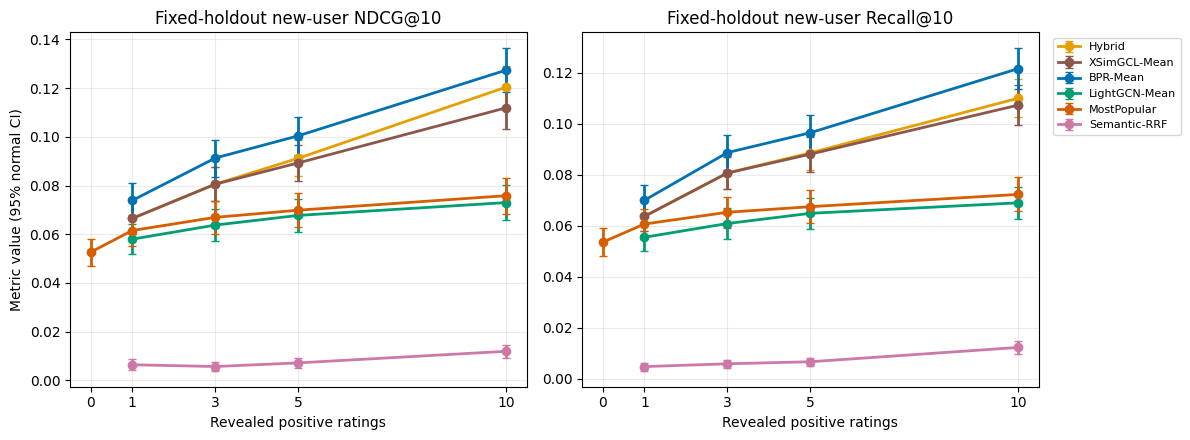

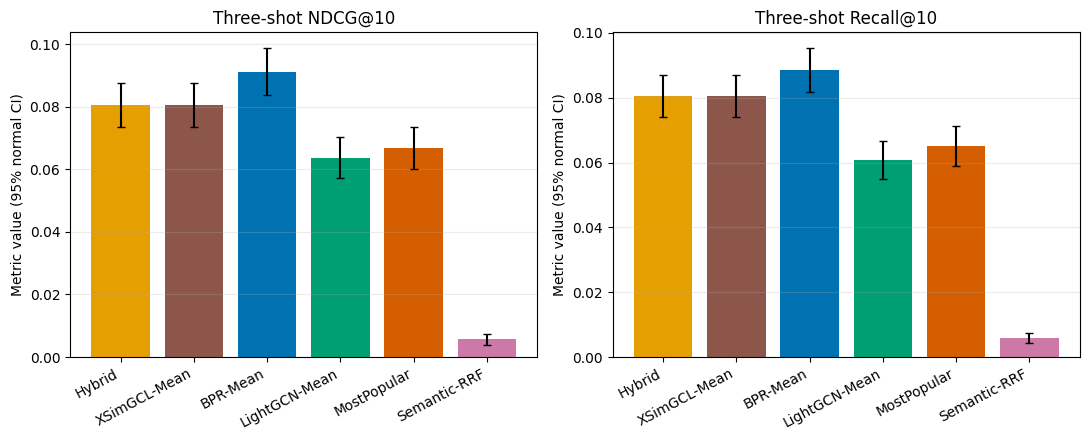

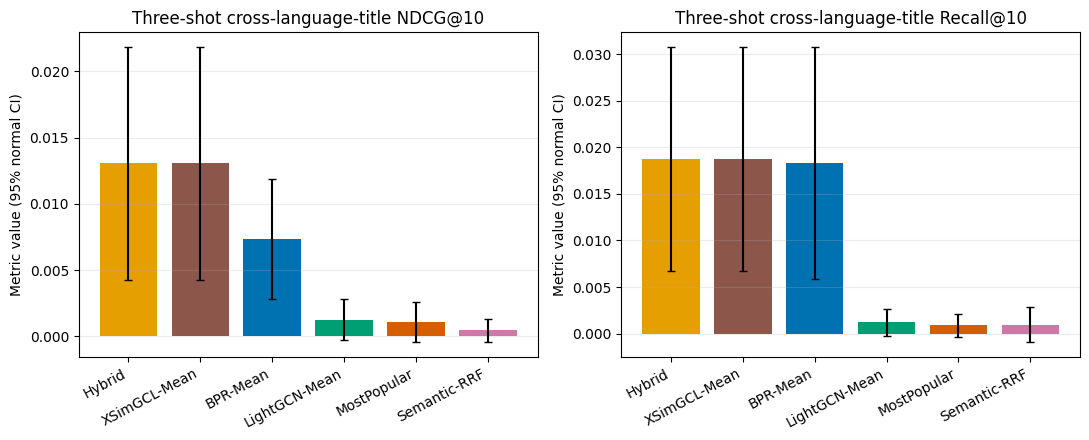

Few-shot evaluation complete: /content/drive/MyDrive/cinematch/outputs/publication_audit/fewshot_new_user_eval
Return these files for paper revision:
 - fewshot_aggregate_metrics.csv
 - fewshot_prespecified_paired_inference.csv
 - fewshot_frozen_alpha_by_shot.json
 - fewshot_cohort_manifest.json
 - fewshot_run_manifest.json
 - fewshot_learning_curves.png
 - fewshot_learning_curves.pdf
 - fewshot_three_shot_comparison.png
 - fewshot_three_shot_comparison.pdf
 - fewshot_cross_language_three_shot.png
 - fewshot_cross_language_three_shot.pdf


In [11]:
# Publication figures with fixed targets and normal-approximation 95% user-level confidence intervals.
METHOD_ORDER = ['Hybrid', 'XSimGCL-Mean', 'BPR-Mean', 'LightGCN-Mean', 'MostPopular', 'Semantic-RRF']
METHOD_COLORS = {
    'Hybrid': '#E69F00', 'XSimGCL-Mean': '#8C564B', 'BPR-Mean': '#0072B2',
    'LightGCN-Mean': '#009E73', 'MostPopular': '#D55E00', 'Semantic-RRF': '#CC79A7',
}

def mean_and_ci(cohort_name, shot, method, metric):
    values = fewshot_per_user.loc[
        fewshot_per_user.cohort.eq(cohort_name)
        & fewshot_per_user.shot.eq(shot)
        & fewshot_per_user.method.eq(method), metric
    ].dropna().to_numpy(dtype=float)
    mean = float(values.mean())
    half_width = float(1.96 * values.std(ddof=1) / math.sqrt(len(values))) if len(values) > 1 else 0.0
    return mean, half_width

primary_plot = fewshot_aggregate.loc[
    fewshot_aggregate.cohort.eq('fewshot_primary')
    & fewshot_aggregate.method.isin(METHOD_ORDER)
].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for method in METHOD_ORDER:
    frame = primary_plot.loc[primary_plot.method.eq(method)].sort_values('shot')
    if frame.empty:
        continue
    for ax, metric in zip(axes, ('NDCG@10', 'Recall@10')):
        points = [mean_and_ci('fewshot_primary', int(shot), method, metric) for shot in frame.shot]
        ax.errorbar(
            frame.shot, [point[0] for point in points], yerr=[point[1] for point in points],
            marker='o', linewidth=2, capsize=3, color=METHOD_COLORS[method], label=method,
        )
axes[0].set_title('Fixed-holdout new-user NDCG@10')
axes[1].set_title('Fixed-holdout new-user Recall@10')
for ax in axes:
    ax.set_xlabel('Revealed positive ratings')
    ax.set_xticks(SHOTS)
    ax.grid(alpha=0.25)
axes[0].set_ylabel('Metric value (95% normal CI)')
axes[1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
learning_png = FEW_OUT / 'fewshot_learning_curves.png'
learning_pdf = FEW_OUT / 'fewshot_learning_curves.pdf'
fig.savefig(learning_png, dpi=300, bbox_inches='tight')
fig.savefig(learning_pdf, bbox_inches='tight')
plt.show()
plt.close(fig)

# Deployment-relevant three-shot architecture comparison.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, metric in zip(axes, ('NDCG@10', 'Recall@10')):
    points = [mean_and_ci('fewshot_primary', 3, method, metric) for method in METHOD_ORDER]
    ax.bar(
        np.arange(len(METHOD_ORDER)), [point[0] for point in points],
        yerr=[point[1] for point in points], capsize=3,
        color=[METHOD_COLORS[method] for method in METHOD_ORDER],
    )
    ax.set_xticks(np.arange(len(METHOD_ORDER)), METHOD_ORDER, rotation=28, ha='right')
    ax.set_title(f'Three-shot {metric}')
    ax.set_ylabel('Metric value (95% normal CI)')
    ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
comparison_png = FEW_OUT / 'fewshot_three_shot_comparison.png'
comparison_pdf = FEW_OUT / 'fewshot_three_shot_comparison.pdf'
fig.savefig(comparison_png, dpi=300, bbox_inches='tight')
fig.savefig(comparison_pdf, bbox_inches='tight')
plt.show()
plt.close(fig)

# Secondary title-language subset; this is retrieval evidence, not a culture label.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, metric in zip(axes, ('NDCG@10', 'Recall@10')):
    points = [mean_and_ci('fewshot_cross_language', 3, method, metric) for method in METHOD_ORDER]
    ax.bar(
        np.arange(len(METHOD_ORDER)), [point[0] for point in points],
        yerr=[point[1] for point in points], capsize=3,
        color=[METHOD_COLORS[method] for method in METHOD_ORDER],
    )
    ax.set_xticks(np.arange(len(METHOD_ORDER)), METHOD_ORDER, rotation=28, ha='right')
    ax.set_title(f'Three-shot cross-language-title {metric}')
    ax.set_ylabel('Metric value (95% normal CI)')
    ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
cross_png = FEW_OUT / 'fewshot_cross_language_three_shot.png'
cross_pdf = FEW_OUT / 'fewshot_cross_language_three_shot.pdf'
fig.savefig(cross_png, dpi=300, bbox_inches='tight')
fig.savefig(cross_pdf, bbox_inches='tight')
plt.show()
plt.close(fig)

figure_paths = [learning_png, learning_pdf, comparison_png, comparison_pdf, cross_png, cross_pdf]

result_paths = [
    FEW_OUT / 'fewshot_cohort_manifest.json',
    FEW_OUT / 'fewshot_validation_alpha_grid.csv',
    FEW_OUT / 'fewshot_frozen_alpha_by_shot.json',
    FEW_OUT / 'fewshot_aggregate_metrics.csv',
    FEW_OUT / 'fewshot_per_user_metrics.csv',
    FEW_OUT / 'fewshot_prespecified_paired_inference.csv',
    *figure_paths,
]
run_manifest = {
    'completed_utc': pd.Timestamp.utcnow().isoformat(),
    'protocol': 'strict first-seen-after-cutoff few-shot new-user evaluation with fixed positions 11-20 as targets',
    'no_retraining': True,
    'trained_user_embeddings_used': False,
    'cf_proxy': 'L2-normalized mean of only the revealed positive item embeddings',
    'semantic_method': 'exact FAISS over the frozen common candidate catalog, per-liked-title retrieval with reciprocal-rank fusion',
    'selection': json.loads(weights_path.read_text()),
    'cohorts': cohort_payload,
    'paired_inference': {
        'shots': list(INFERENCE_SHOTS),
        'pairs': [list(pair) for pair in INFERENCE_PAIRS],
        'metrics': list(INFERENCE_METRICS),
        'holm_family_size_by_cohort': fewshot_inference.groupby('inference_family').size().astype(int).to_dict(),
    },
    'limitations': [
        'MovieLens timestamps indicate rating events, not verified viewing order.',
        'The common-catalog restriction isolates model-path quality but is smaller than the production catalog.',
        'Requiring twenty future positive ratings selects an active-new-user cohort and is not representative of every new user.',
        'Zero-shot personalization is undefined without demographic or onboarding information.',
        'Title language is not a user-culture label.',
    ],
    'versions': {
        'python': platform.python_version(),
        'numpy': np.__version__,
        'pandas': pd.__version__,
        'torch': torch.__version__,
        'faiss': getattr(faiss, '__version__', 'unknown'),
    },
    'outputs_sha256': {path.name: sha256_file(path) for path in result_paths},
}
run_manifest_path = FEW_OUT / 'fewshot_run_manifest.json'
run_manifest_path.write_text(json.dumps(run_manifest, indent=2))

print('Few-shot evaluation complete:', FEW_OUT)
print('Return these files for paper revision:')
for path in [
    FEW_OUT / 'fewshot_aggregate_metrics.csv',
    FEW_OUT / 'fewshot_prespecified_paired_inference.csv',
    FEW_OUT / 'fewshot_frozen_alpha_by_shot.json',
    FEW_OUT / 'fewshot_cohort_manifest.json',
    run_manifest_path,
    *figure_paths,
]:
    print(' -', path.name)


## How to interpret the result

The strongest evidence would be a positive, Holm-significant Hybrid difference against the strongest graph baseline at one or three shots, together with a positive Hybrid minus Semantic-RRF difference. Because positions 11-20 are fixed targets, changes across shot counts now isolate the information added by the revealed ratings.

If Hybrid ties one component, report the tie. If semantic retrieval wins by itself at one shot, that is still valuable evidence: it identifies where Path A, rather than fusion, is responsible for cold-user adaptation.

Use the primary fixed-holdout cohort for the main claim. Treat the cross-language-title cohort and catalog coverage as secondary evidence. Do not describe the zero-shot Popularity result as semantic performance, and do not call the title-language subset a cultural or fairness evaluation.
